# Урок 13.1. Ранжирование: LambdaMART

**Интерактивная версия:** `lessons/lesson_13_1/web/index.html`

1. DCG и NDCG вручную.
2. Лямбды одного запроса: RankNet против LambdaRank.
3. LambdaMART своими руками (`examples/lambdamart.py`) против LightGBM и XGBoost.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "shared" / "python" / "gbcourse").is_dir())
sys.path.insert(0, str(ROOT / "shared" / "python"))
sys.path.insert(0, str(ROOT / "lessons" / "lesson_13_1" / "examples"))

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb
from gbcourse import GBRegressor
from gbcourse.plotting import use_course_style
from lambdamart import LambdaMART, dcg, lambdas, make_queries, ndcg_at_k

use_course_style()

## 1. DCG вручную

Модель поставила документы с оценками (3, 0, 2, 1) в этом порядке.

In [2]:
rel = [3, 0, 2, 1]
terms = [(2**r - 1) / np.log2(i + 2) for i, r in enumerate(rel)]
print("слагаемые DCG:", np.round(terms, 3), "→ DCG =", round(sum(terms), 4))
ideal = dcg(sorted(rel, reverse=True), 4)
print(f"идеальный DCG = {ideal:.4f}, NDCG@4 = {dcg(rel, 4) / ideal:.4f}")

слагаемые DCG: [7.    0.    1.5   0.431] → DCG = 8.9307
идеальный DCG = 9.3928, NDCG@4 = 0.9508


## 2. Лямбды одного запроса

In [3]:
scores = np.array([0.5, 0.4, 0.3, 0.2, 0.1])
rel_q = np.array([0, 1, 0, 3, 2])
qid_q = np.zeros(5, dtype=int)
for weighted in (False, True):
    g, _ = lambdas(scores, rel_q, qid_q, k=5, weight_ndcg=weighted)
    print(("LambdaRank" if weighted else "RankNet   ") + ": −g (сила «вверх») =", np.round(-g, 3))

RankNet   : −g (сила «вверх») = [-1.698 -0.124 -1.55   2.124  1.248]
LambdaRank: −g (сила «вверх») = [-0.382 -0.073 -0.054  0.35   0.158]


В RankNet сила зависит только от «неправильных» пар и того, насколько уверенно они перепутаны (ρ), но не от позиций.
В LambdaRank документ с rel = 3 на 4-й позиции
тянется вверх сильнее всех: его перестановка наверх больше всего поднимает NDCG.

## 3. Сравнение моделей

In [4]:
X, rel, qid = make_queries(150, seed=200)
Xt, relt, qidt = make_queries(150, seed=201)
res = {"случайный порядок": ndcg_at_k(np.random.default_rng(0).random(len(relt)), relt, qidt),
       "регрессия на оценки": ndcg_at_k(GBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1).fit(X, rel).predict(Xt), relt, qidt)}
ranknet = LambdaMART(n_estimators=100, weight_ndcg=False).fit(X, rel, qid, eval_set=(Xt, relt, qidt))
res["RankNet (без веса ΔNDCG)"] = ranknet.history_[-1]
ours = LambdaMART(n_estimators=100).fit(X, rel, qid, eval_set=(Xt, relt, qidt))
res["LambdaMART своими руками"] = ours.history_[-1]
res["LightGBM lambdarank"] = ndcg_at_k(lgb.LGBMRanker(n_estimators=100, learning_rate=0.1, num_leaves=16, verbose=-1)
                                       .fit(X, rel, group=np.bincount(qid)).predict(Xt), relt, qidt)
res["XGBoost rank:ndcg"] = ndcg_at_k(xgb.XGBRanker(n_estimators=100, learning_rate=0.1, max_depth=4, objective="rank:ndcg")
                                     .fit(X, rel, qid=qid).predict(Xt), relt, qidt)
pd.Series(res, name="NDCG@10").round(4)

случайный порядок           0.5067
регрессия на оценки         0.8860
RankNet (без веса ΔNDCG)    0.8661
LambdaMART своими руками    0.8893
LightGBM lambdarank         0.9009
XGBoost rank:ndcg           0.8911
Name: NDCG@10, dtype: float64

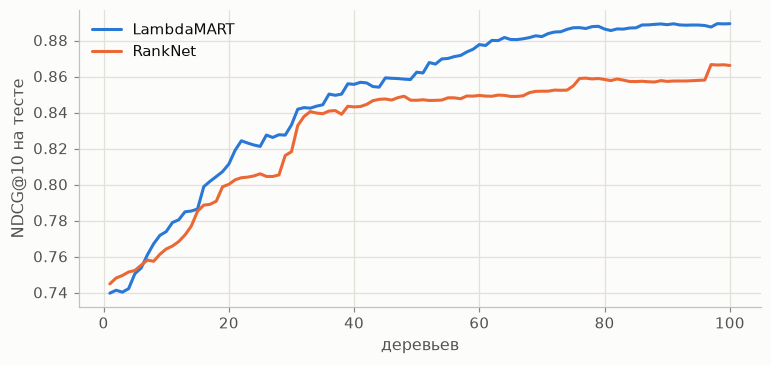

In [5]:
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(np.arange(1, 101), ours.history_, label="LambdaMART")
ax.plot(np.arange(1, 101), ranknet.history_, label="RankNet")
ax.set(xlabel="деревьев", ylabel="NDCG@10 на тесте")
ax.legend()
plt.show()

## Упражнения

1. Посчитайте |ΔNDCG@4| для перестановки 1-го и 3-го документов в примере раздела 1.
2. Сравните NDCG@3 вместо NDCG@10: как меняется разрыв между регрессией и LambdaMART?

Решения: `python lessons/lesson_13_1/exercises/solutions.py`.